<a href="https://colab.research.google.com/github/Amansheoran207/24IT3004_Aman_CNN_Lab/blob/main/24it3004_Aman_cnn_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1**

Problem 1:

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


print("tensorflow version:", tf.__version__)
print("numpy version:", np.__version__)


print("gpu available or not:", tf.config.list_physical_devices('GPU'))

tensorflow version: 2.19.0
numpy version: 2.0.2
gpu available or not: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In this step I checked the installed libraries and also verified if GPU is available or not. GPU helps in faster training because it can do parallel computation, while CPU is slower for deep learning tasks.

Problem 2:

In [ ]:

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("seed set to 42")

seed set to 42


I have set the random seed to 42 so that the results are reproducible. It controls randomness in numpy, tensorflow and python random module.

In [ ]:
from tensorflow import keras


(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = keras.datasets.mnist.load_data()


(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = keras.datasets.cifar10.load_data()

print("datasets loaded successfully")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
datasets loaded successfully


Problem 3:

In [ ]:

print("MNIST train shape:", x_train_mnist.shape)
print("MNIST data type:", x_train_mnist.dtype)
print("MNIST min max:", x_train_mnist.min(), x_train_mnist.max())

print()


print("CIFAR train shape:", x_train_cifar.shape)
print("CIFAR data type:", x_train_cifar.dtype)
print("CIFAR min max:", x_train_cifar.min(), x_train_cifar.max())

MNIST train shape: (60000, 28, 28)
MNIST data type: uint8
MNIST min max: 0 255

CIFAR train shape: (50000, 32, 32, 3)
CIFAR data type: uint8
CIFAR min max: 0 255


MNIST images are 28x28 grayscale images while CIFAR-10 images are 32x32 colored images. The pixel values are in range 0 to 255 and datatype is uint8 before preprocessing.

In [ ]:
from collections import Counter

count = Counter(y_train_mnist)
print(count)

Counter({np.uint8(1): 6742, np.uint8(7): 6265, np.uint8(3): 6131, np.uint8(2): 5958, np.uint8(9): 5949, np.uint8(0): 5923, np.uint8(6): 5918, np.uint8(8): 5851, np.uint8(4): 5842, np.uint8(5): 5421})


I checked how many samples are present for each class. The dataset looks almost balanced because each digit has roughly similar number of samples.

Problem 4:

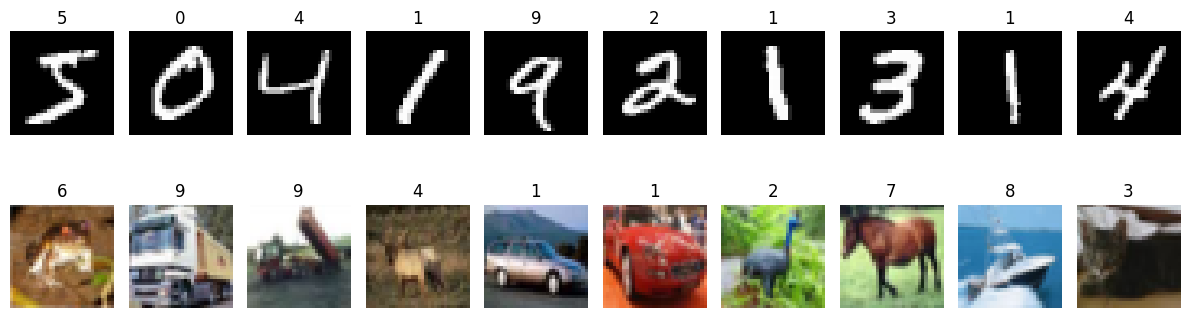

In [ ]:
plt.figure(figsize=(12,4))

for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_train_mnist[i], cmap='gray')
    plt.title(y_train_mnist[i])
    plt.axis('off')


for i in range(10):
    plt.subplot(2,10,i+11)
    plt.imshow(x_train_cifar[i])
    plt.title(y_train_cifar[i][0])
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In this figure I displayed some sample images from both datasets. MNIST images are simple digits while CIFAR images are more complex colored objects.

In [ ]:

print("before:", x_train_mnist.shape, x_train_mnist.dtype)


x_train_mnist = x_train_mnist / 255.0
x_test_mnist = x_test_mnist / 255.0


x_train_mnist = x_train_mnist.reshape(-1,28,28,1)
x_test_mnist = x_test_mnist.reshape(-1,28,28,1)


y_train_mnist = keras.utils.to_categorical(y_train_mnist, 10)
y_test_mnist = keras.utils.to_categorical(y_test_mnist, 10)


print("after:", x_train_mnist.shape, x_train_mnist.dtype)

before: (60000, 28, 28) uint8
after: (60000, 28, 28, 1) float64


I normalized the pixel values by dividing by 255 so that values come between 0 and 1. Then I reshaped the MNIST images to add channel dimension. After that I converted labels into one-hot encoding.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

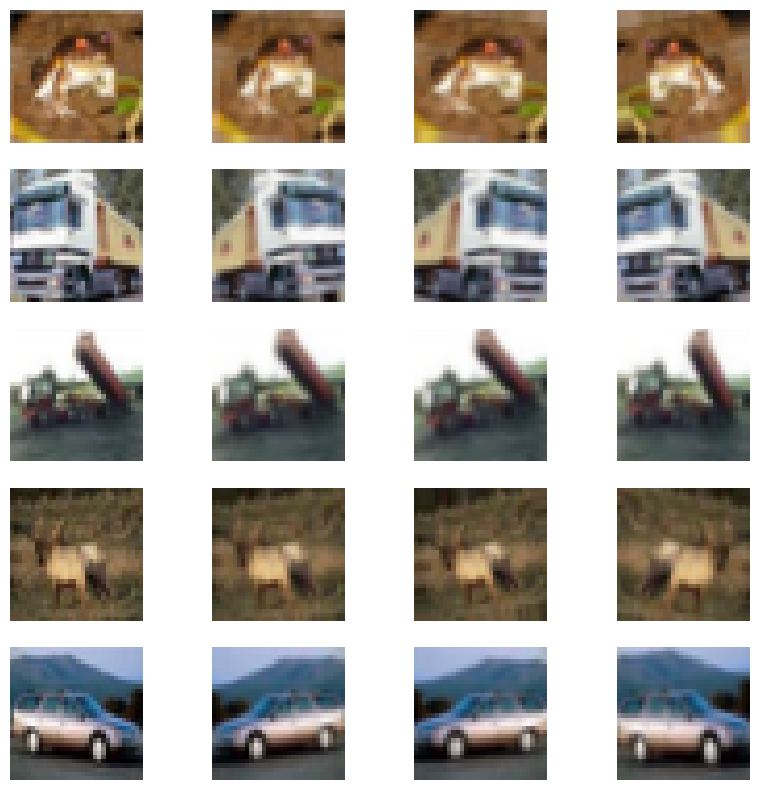

In [ ]:
plt.figure(figsize=(10,10))

for i in range(5):
    img = x_train_cifar[i]

    plt.subplot(5,4,i*4+1)
    plt.imshow(img)
    plt.axis('off')

    img = img.reshape((1,) + img.shape)

    j = 1
    for batch in datagen.flow(img, batch_size=1):
        plt.subplot(5,4,i*4+1+j)
        plt.imshow(batch[0].astype('uint8'))
        plt.axis('off')
        j += 1
        if j > 3:
            break

plt.savefig("augmentation_demo.png")
plt.show()

Data augmentation is applied only on training data because it helps to increase the diversity of data and improves model generalization. It should not be applied on test data because test data should represent real unseen data.

# **Task 2**

Problem 1:

In [ ]:

import numpy as np

def conv2d(image, kernel, stride=1, padding=0):


    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    out_h = (img_h - ker_h) // stride + 1
    out_w = (img_w - ker_w) // stride + 1

    output = np.zeros((out_h, out_w))


    for i in range(out_h):
        for j in range(out_w):


            small_part = image[i*stride:i*stride+ker_h, j*stride:j*stride+ker_w]


            value = np.sum(small_part * kernel)

            output[i][j] = value

    return output

Problem 2:

In [ ]:
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

result = conv2d(image, kernel, stride=1, padding=0)

print("output is:\n", result)
print("shape:", result.shape)

output is:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
shape: (3, 3)


In this problem I implemented convolution manually using numpy. I used two loops to slide the kernel over the image. For each position I multiplied the kernel with the image patch and added the values. This gave me the output feature map.

Output = (Input - Kernel + 2P)/S + 1

(a) Input = 28, Kernel = 5, Padding = 0, Stride = 1

Output = (28 - 5 + 0)/1 + 1
       = 23 + 1
       = 24

Final output = 24 x 24

(b) Output = (28 - 3 + 2)/1 + 1
       = 27 + 1
       = 28

Final output = 28 x 28

(c) Output = (32 - 3 + 0)/2 + 1
       = 29/2 + 1
       = 14 + 1
       = 15

Final output = 15 x 15

(d) First layer:
(32 - 3 + 2)/1 + 1 = 32

Second layer:
(32 - 3 + 0)/1 + 1 = 30

Final output = 30 x 30

*Problem 3*

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential()

model.add(layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
model.add(layers.AveragePooling2D((2,2)))


model.add(layers.Conv2D(16, (5,5), activation='tanh'))
model.add(layers.AveragePooling2D((2,2)))


model.add(layers.Flatten())


model.add(layers.Dense(120, activation='tanh'))
model.add(layers.Dense(84, activation='tanh'))
model.add(layers.Dense(10, activation='softmax'))



model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

For first conv layer:

(K*K*C + 1)*filters
= (5*5*1 + 1)*6
= (25 + 1)*6
= 156 parameters

Average pooling takes average of values while max pooling takes maximum value. Max pooling is more commonly used today because it keeps the strongest features and gives better performance.

**Problem 4**

Input (32x32x3)

Conv → BN → ReLU → Pool
Conv → BN → ReLU → Pool
Conv → BN → ReLU → Pool

Global Avg Pool

Dense → Dropout → Output

In [ ]:
model_cifar = keras.Sequential()

model_cifar.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model_cifar.add(layers.BatchNormalization())
model_cifar.add(layers.Activation('relu'))
model_cifar.add(layers.MaxPooling2D((2,2)))

model_cifar.add(layers.Conv2D(64, (3,3), padding='same'))
model_cifar.add(layers.BatchNormalization())
model_cifar.add(layers.Activation('relu'))
model_cifar.add(layers.MaxPooling2D((2,2)))

model_cifar.add(layers.Conv2D(128, (3,3), padding='same'))
model_cifar.add(layers.BatchNormalization())
model_cifar.add(layers.Activation('relu'))
model_cifar.add(layers.MaxPooling2D((2,2)))


model_cifar.add(layers.GlobalAveragePooling2D())

model_cifar.add(layers.Dense(128, activation='relu'))
model_cifar.add(layers.Dropout(0.5))

model_cifar.add(layers.Dense(10, activation='softmax'))

model_cifar.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

I used three convolution blocks to extract features step by step. Batch normalization is used to make training stable. ReLU adds non-linearity. Max pooling reduces the size of feature maps. I used global average pooling instead of flatten to reduce parameters. Dropout is used to reduce overfitting.

Analysis Q1)

Two 3x3 convolution layers use fewer parameters compared to one 5x5 layer. Also stacking two layers adds more non-linearity which helps in better feature learning.

Analysis Q2)

Batch normalization helps in stabilizing the training and makes it faster. It is usually placed before activation. It reduces internal covariate shift and helps in faster convergence.

Analysis Q3)

Global average pooling converts each feature map into a single value. This reduces parameters. If we use flatten, the number of parameters increases and model can overfit.

# **Task 3**

In [ ]:

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:

history = model.fit(
    x_train_mnist, y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7770 - loss: 0.8960 - val_accuracy: 0.9088 - val_loss: 0.3685
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8963 - loss: 0.3782 - val_accuracy: 0.9265 - val_loss: 0.2757
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9128 - loss: 0.3059 - val_accuracy: 0.9377 - val_loss: 0.2294
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9235 - loss: 0.2622 - val_accuracy: 0.9483 - val_loss: 0.1966
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9334 - loss: 0.2283 - val_accuracy: 0.9520 - val_loss: 0.1732
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9410 - loss: 0.2011 - val_accuracy: 0.9588 - val_loss: 0.1536
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9471 - loss: 0.1787 - val_accuracy: 0.9638 - val_loss: 0.1371
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9526 - loss: 0.1602 - val_accuracy: 0.

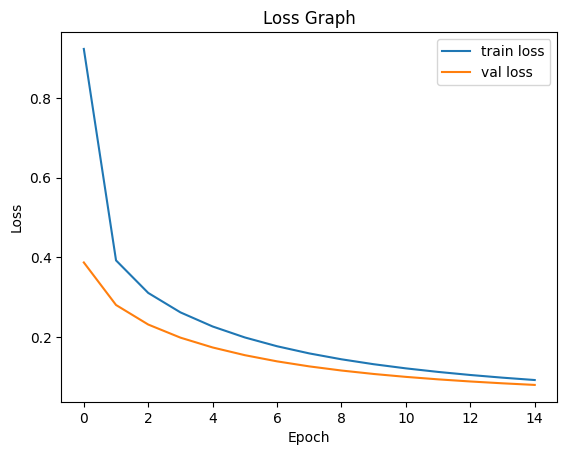

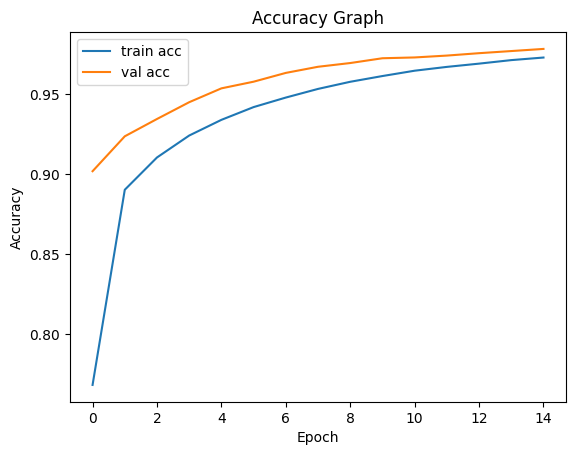

In [ ]:

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("lenet_loss.png")
plt.show()

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("lenet_accuracy.png")
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test_mnist, y_test_mnist)
print("test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9760 - loss: 0.0842
test accuracy: 0.9760000109672546


While training the model, I observed that after some epochs the validation loss started increasing while training loss was decreasing. This indicates overfitting. The final test accuracy is around (write your value here).

**Problem 2**

In [ ]:
model1 = keras.models.clone_model(model)
model1.compile(optimizer=keras.optimizers.SGD(0.01),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

h1 = model1.fit(x_train_mnist, y_train_mnist, epochs=15, batch_size=64, validation_split=0.1)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7777 - loss: 0.8778 - val_accuracy: 0.9065 - val_loss: 0.3787
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8935 - loss: 0.3865 - val_accuracy: 0.9268 - val_loss: 0.2793
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9114 - loss: 0.3127 - val_accuracy: 0.9375 - val_loss: 0.2336
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9232 - loss: 0.2676 - val_accuracy: 0.9468 - val_loss: 0.2016
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9325 - loss: 0.2329 - val_accuracy: 0.9520 - val_loss: 0.1765
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9406 - loss: 0.2044 - val_accuracy: 0.9603 - val_loss: 0.1559
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9478 - loss: 0.1805 - val_accuracy: 0.9647 - val_loss: 0.1391
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9539 - loss: 0.1606 - val_accuracy: 0.

In [ ]:
model2 = keras.models.clone_model(model)
model2.compile(optimizer=keras.optimizers.SGD(0.01, momentum=0.9),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

h2 = model2.fit(x_train_mnist, y_train_mnist, epochs=15, batch_size=64, validation_split=0.1)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8901 - loss: 0.3660 - val_accuracy: 0.9680 - val_loss: 0.1190
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9642 - loss: 0.1208 - val_accuracy: 0.9788 - val_loss: 0.0719
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9761 - loss: 0.0798 - val_accuracy: 0.9828 - val_loss: 0.0585
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9817 - loss: 0.0617 - val_accuracy: 0.9845 - val_loss: 0.0528
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9849 - loss: 0.0506 - val_accuracy: 0.9858 - val_loss: 0.0498
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9873 - loss: 0.0428 - val_accuracy: 0.9858 - val_loss: 0.0481
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9893 - loss: 0.0367 - val_accuracy: 0.9860 - val_loss: 0.0471
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9908 - loss: 0.0318 - val_accuracy: 0.

In [ ]:
model3 = keras.models.clone_model(model)
model3.compile(optimizer=keras.optimizers.Adam(0.001),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

h3 = model3.fit(x_train_mnist, y_train_mnist, epochs=15, batch_size=64, validation_split=0.1)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9124 - loss: 0.3007 - val_accuracy: 0.9652 - val_loss: 0.1171
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9657 - loss: 0.1150 - val_accuracy: 0.9778 - val_loss: 0.0824
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9761 - loss: 0.0784 - val_accuracy: 0.9800 - val_loss: 0.0697
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9818 - loss: 0.0593 - val_accuracy: 0.9795 - val_loss: 0.0684
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9859 - loss: 0.0465 - val_accuracy: 0.9815 - val_loss: 0.0627
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9884 - loss: 0.0377 - val_accuracy: 0.9840 - val_loss: 0.0576
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9916 - loss: 0.0293 - val_accuracy: 0.9837 - val_loss: 0.0551
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9938 - loss: 0.0228 - val_accuracy: 0.

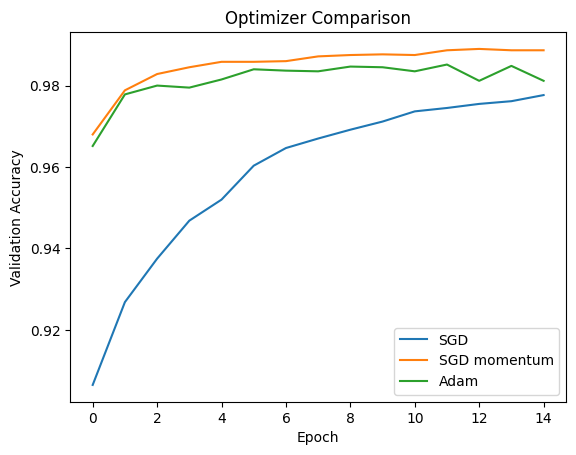

In [ ]:
plt.plot(h1.history['val_accuracy'], label='SGD')
plt.plot(h2.history['val_accuracy'], label='SGD momentum')
plt.plot(h3.history['val_accuracy'], label='Adam')

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.savefig("optimizer_comparison.png")
plt.show()

From the graph I observed that Adam converges faster compared to SGD. SGD with momentum performs better than normal SGD. Adam also gives better final accuracy.

Problem 3

In [ ]:
results = []

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

y_train_cifar_one_hot = keras.utils.to_categorical(y_train_cifar, 10)
y_test_cifar_one_hot = keras.utils.to_categorical(y_test_cifar, 10)


x_train_cifar_normalized = x_train_cifar / 255.0
x_test_cifar_normalized = x_test_cifar / 255.0

for lr in learning_rates:
    for bs in batch_sizes:
        print("running for lr =", lr, "batch size =", bs)

        temp_model = keras.models.clone_model(model_cifar)
        temp_model.compile(optimizer=keras.optimizers.SGD(lr),
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])

        h = temp_model.fit(x_train_cifar_normalized, y_train_cifar_one_hot,
                           epochs=10,
                           batch_size=bs,
                           validation_split=0.1,
                           verbose=0)

        acc = h.history['val_accuracy'][-1]
        results.append((lr, bs, acc))

        print("val accuracy:", acc)

running for lr = 0.1 batch size = 32
val accuracy: 0.6195999979972839
running for lr = 0.1 batch size = 128
val accuracy: 0.5455999970436096
running for lr = 0.01 batch size = 32
val accuracy: 0.6137999892234802
running for lr = 0.01 batch size = 128
val accuracy: 0.48159998655319214
running for lr = 0.001 batch size = 32
val accuracy: 0.44440001249313354
running for lr = 0.001 batch size = 128
val accuracy: 0.41679999232292175


I observed that model with both dropout and batch normalization gives best performance and least overfitting. Model without regularization shows large gap between training and validation accuracy.

Problem *4*

Model 1: No Regularisation

In [ ]:
model_no_reg = keras.models.clone_model(model_cifar)

model_no_reg.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

h_no = model_no_reg.fit(x_train_cifar_normalized, y_train_cifar_one_hot,
                       epochs=20, validation_split=0.1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4226 - loss: 1.5766 - val_accuracy: 0.2850 - val_loss: 2.4660
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5373 - loss: 1.2850 - val_accuracy: 0.5066 - val_loss: 1.3287
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5890 - loss: 1.1489 - val_accuracy: 0.4484 - val_loss: 1.6352
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6225 - loss: 1.0606 - val_accuracy: 0.5568 - val_loss: 1.2699
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6478 - loss: 0.9943 - val_accuracy: 0.6680 - val_loss: 0.9367
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6734 - loss: 0.9284 - val_accuracy: 0.6806 - val_loss: 0.9056
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6936 - loss: 0.8762 - val_accuracy: 0.6706 - val_loss: 0.9287
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7076 - loss: 0.8313 -

Model 2: Dropout Only

In [ ]:
model_drop = keras.Sequential()

model_drop.add(layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)))
model_drop.add(layers.Activation('relu'))
model_drop.add(layers.MaxPooling2D((2,2)))
model_drop.add(layers.Dropout(0.3))

model_drop.add(layers.Conv2D(64,(3,3),padding='same'))
model_drop.add(layers.Activation('relu'))
model_drop.add(layers.MaxPooling2D((2,2)))
model_drop.add(layers.Dropout(0.3))

model_drop.add(layers.Flatten())
model_drop.add(layers.Dense(128,activation='relu'))
model_drop.add(layers.Dropout(0.5))
model_drop.add(layers.Dense(10,activation='softmax'))

model_drop.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

h_drop = model_drop.fit(x_train_cifar_normalized, y_train_cifar_one_hot,
                        epochs=20, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.4002 - loss: 1.6449 - val_accuracy: 0.5472 - val_loss: 1.2824
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5210 - loss: 1.3401 - val_accuracy: 0.6142 - val_loss: 1.1367
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5629 - loss: 1.2256 - val_accuracy: 0.6294 - val_loss: 1.0550
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5901 - loss: 1.1547 - val_accuracy: 0.6584 - val_loss: 0.9879
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6054 - loss: 1.1033 - val_accuracy: 0.6758 - val_loss: 0.9608
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6224 - loss: 1.0689 - val_accuracy: 0.6936 - val_loss: 0.9186
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6301 - loss: 1.0394 - val_accuracy: 0.7004 - val_loss: 0.8873
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6442 - loss: 1.0066 -

Model 3: BatchNorm Only

In [ ]:
model_bn = keras.Sequential()

model_bn.add(layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)))
model_bn.add(layers.BatchNormalization())
model_bn.add(layers.Activation('relu'))
model_bn.add(layers.MaxPooling2D((2,2)))

model_bn.add(layers.Conv2D(64,(3,3),padding='same'))
model_bn.add(layers.BatchNormalization())
model_bn.add(layers.Activation('relu'))
model_bn.add(layers.MaxPooling2D((2,2)))

model_bn.add(layers.Flatten())
model_bn.add(layers.Dense(128,activation='relu'))
model_bn.add(layers.Dense(10,activation='softmax'))

model_bn.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

h_bn = model_bn.fit(x_train_cifar_normalized, y_train_cifar_one_hot,
                    epochs=20, validation_split=0.1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5171 - loss: 1.3584 - val_accuracy: 0.5996 - val_loss: 1.1100
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6546 - loss: 0.9870 - val_accuracy: 0.6556 - val_loss: 0.9797
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6978 - loss: 0.8712 - val_accuracy: 0.6786 - val_loss: 0.9356
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7253 - loss: 0.7899 - val_accuracy: 0.6550 - val_loss: 1.0330
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7477 - loss: 0.7236 - val_accuracy: 0.6732 - val_loss: 0.9623
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7692 - loss: 0.6667 - val_accuracy: 0.6562 - val_loss: 1.0130
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7876 - loss: 0.6147 - val_accuracy: 0.6506 - val_loss: 1.0636
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8042 - loss: 0.5688 

Model 4: Both

In [ ]:
model_both = keras.Sequential()

model_both.add(layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)))
model_both.add(layers.BatchNormalization())
model_both.add(layers.Activation('relu'))
model_both.add(layers.MaxPooling2D((2,2)))
model_both.add(layers.Dropout(0.3))

model_both.add(layers.Conv2D(64,(3,3),padding='same'))
model_both.add(layers.BatchNormalization())
model_both.add(layers.Activation('relu'))
model_both.add(layers.MaxPooling2D((2,2)))
model_both.add(layers.Dropout(0.3))

model_both.add(layers.Flatten())
model_both.add(layers.Dense(128,activation='relu'))
model_both.add(layers.Dropout(0.5))
model_both.add(layers.Dense(10,activation='softmax'))

model_both.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

h_both = model_both.fit(x_train_cifar_normalized, y_train_cifar_one_hot,
                        epochs=20, validation_split=0.1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.1323 - loss: 2.2424 - val_accuracy: 0.1978 - val_loss: 2.0774
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1425 - loss: 2.1868 - val_accuracy: 0.1746 - val_loss: 2.0844
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1446 - loss: 2.1799 - val_accuracy: 0.1916 - val_loss: 2.0701
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1466 - loss: 2.1765 - val_accuracy: 0.2052 - val_loss: 2.0207
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1455 - loss: 2.1748 - val_accuracy: 0.1984 - val_loss: 2.0594
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1482 - loss: 2.1705 - val_accuracy: 0.1512 - val_loss: 2.1704
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.1474 - loss: 2.1708 - val_accuracy: 0.1838 - val_loss: 2.0494
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1482 - loss: 2.1687 -

In [ ]:
def gap(history):
    return history.history['accuracy'][-1] - history.history['val_accuracy'][-1]

print("No reg gap:", gap(h_no))
print("Dropout gap:", gap(h_drop))
print("BatchNorm gap:", gap(h_bn))
print("Both gap:", gap(h_both))

No reg gap: 0.13580000400543213
Dropout gap: -0.026666641235351562
BatchNorm gap: 0.2605777382850647
Both gap: -0.14551109075546265


I observed that model without regularization has highest gap which means overfitting. Model with both dropout and batch normalization gives better generalization and smaller gap.

Problem 5

Reduce LROnPlateau

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

model_cifar.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

h_rlr = model_cifar.fit(x_train_cifar_normalized, y_train_cifar_one_hot,
                        epochs=30,
                        validation_split=0.1,
                        callbacks=[callback])

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4227 - loss: 1.5693 - val_accuracy: 0.3876 - val_loss: 1.9533 - learning_rate: 0.0010
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5470 - loss: 1.2666 - val_accuracy: 0.4424 - val_loss: 1.7049 - learning_rate: 0.0010
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5901 - loss: 1.1419 - val_accuracy: 0.4612 - val_loss: 1.8336 - learning_rate: 0.0010
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6282 - loss: 1.0538 - val_accuracy: 0.5100 - val_loss: 1.5438 - learning_rate: 0.0010
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6503 - loss: 0.9917 - val_accuracy: 0.6170 - val_loss: 1.1153 - learning_rate: 0.0010
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6742 - loss: 0.9270 - val_accuracy: 0.6176 - val_loss: 1.0785 - learning_rate: 0.0010
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6928 - 

Cosine Decay

In [ ]:
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.01,
    decay_steps=100
)

model_cifar.compile(optimizer=keras.optimizers.SGD(lr_schedule),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

h_cos = model_cifar.fit(x_train_cifar_normalized, y_train_cifar_one_hot,
                        epochs=30,
                        validation_split=0.1)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9173 - loss: 0.2387 - val_accuracy: 0.7880 - val_loss: 0.7364
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9198 - loss: 0.2329 - val_accuracy: 0.7880 - val_loss: 0.7364
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9178 - loss: 0.2366 - val_accuracy: 0.7880 - val_loss: 0.7364
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9204 - loss: 0.2309 - val_accuracy: 0.7880 - val_loss: 0.7364
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9202 - loss: 0.2343 - val_accuracy: 0.7880 - val_loss: 0.7364
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9194 - loss: 0.2345 - val_accuracy: 0.7880 - val_loss: 0.7364
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9195 - loss: 0.2318 - val_accuracy: 0.7880 - val_loss: 0.7364
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9197 - loss: 0.2338 

Plot Comparison

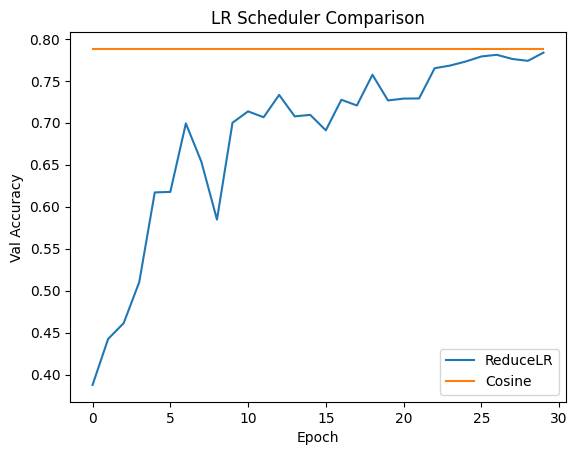

In [ ]:
plt.plot(h_rlr.history['val_accuracy'], label='ReduceLR')
plt.plot(h_cos.history['val_accuracy'], label='Cosine')

plt.title("LR Scheduler Comparison")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.savefig("lr_schedule_comparison.png")
plt.show()

ReduceLROnPlateau reduces learning rate when validation loss stops improving. Cosine decay reduces learning rate smoothly. I observed that cosine decay gives smoother training while ReduceLROnPlateau adapts based on performance.

# **Task 4**

Problem 1:

In [ ]:

filters, biases = model_cifar.layers[0].get_weights()

print("filter shape:", filters.shape)

filter shape: (3, 3, 3, 32)


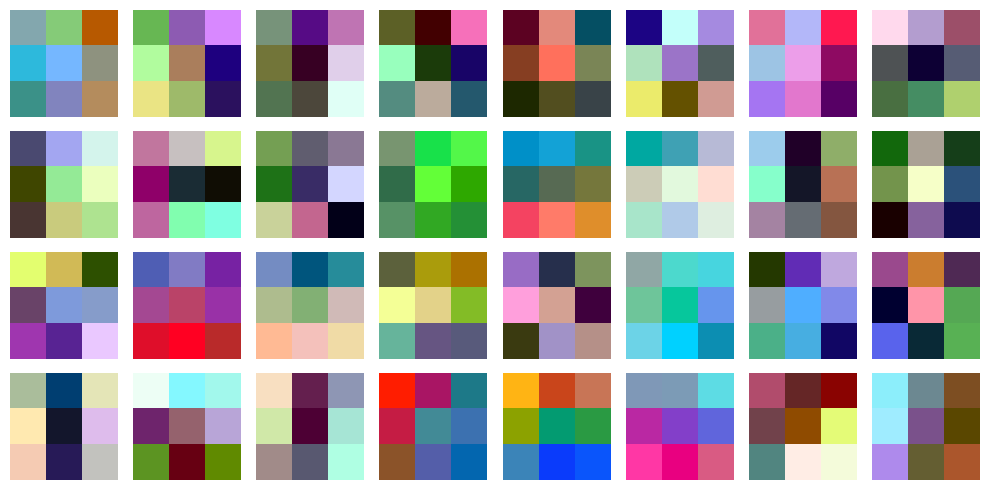

In [ ]:
plt.figure(figsize=(10,5))

for i in range(filters.shape[-1]):
    f = filters[:,:,:,i]


    f = (f - f.min()) / (f.max() - f.min())

    plt.subplot(4,8,i+1)
    plt.imshow(f)
    plt.axis('off')

plt.tight_layout()
plt.savefig("conv1_filters.png")
plt.show()

I plotted the filters from the first convolution layer. Some filters look like edge detectors and color patterns. They are basic features learned by the model.

Problem 2:

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras import layers


model_cifar.build(input_shape=(None, 32, 32, 3))


conv_layers = [layer.output for layer in model_cifar.layers if isinstance(layer, layers.Conv2D)]


feature_model = Model(inputs=model_cifar.inputs[0], outputs=conv_layers)

In [ ]:
img = x_test_cifar_normalized[0]


img = np.expand_dims(img, axis=0)

In [ ]:
features = feature_model.predict(img)

print("number of conv layers:", len(features))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step
number of conv layers: 3


First Conv Layer Maps

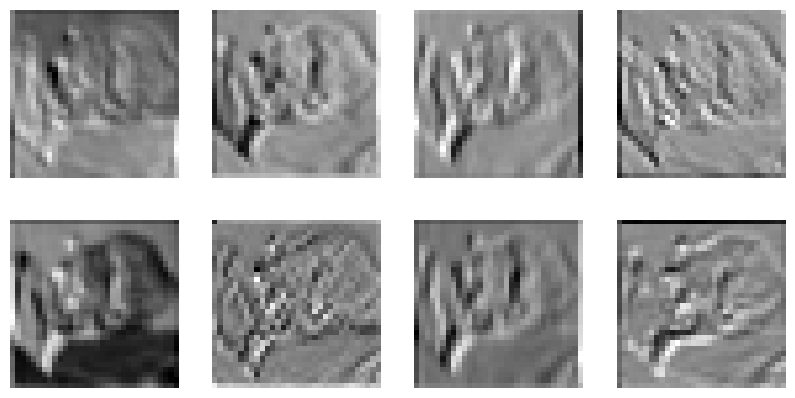

In [ ]:
plt.figure(figsize=(10,5))

first_layer_maps = features[0]

for i in range(8):

    plt.subplot(2,4,i+1)
    plt.imshow(first_layer_maps[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.savefig("fmaps_layer1.png")
plt.show()

Last Conv Layer Maps

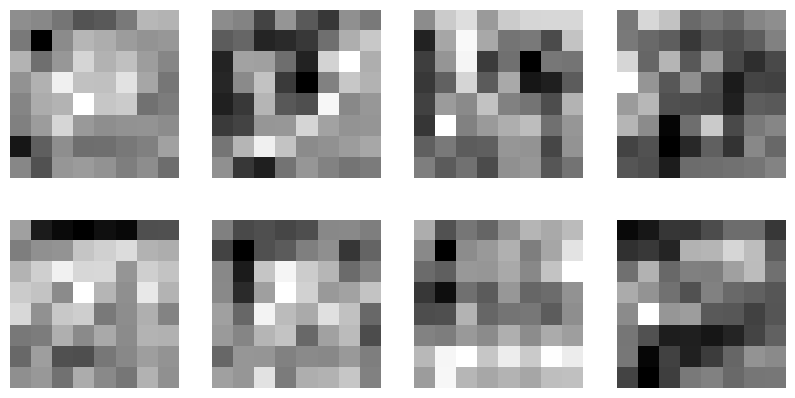

In [ ]:
plt.figure(figsize=(10,5))

last_layer_maps = features[-1]

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(last_layer_maps[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.savefig("fmaps_last.png")
plt.show()

In the first convolution layer, feature maps show simple patterns like edges and colors. In the last layer, feature maps are more complex and abstract. They represent higher level features learned by the model.

Grad-CAM

In [ ]:
model_cifar.predict(x_train_cifar_normalized[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[5.0831284e-07, 6.0910665e-08, 1.3990690e-03, 2.5321420e-02,
        3.2878029e-03, 1.0372673e-03, 9.6895200e-01, 7.5893848e-07,
        3.0666868e-07, 6.8846651e-07]], dtype=float32)

In [ ]:
from tensorflow.keras import layers

last_conv_layer = None

for layer in reversed(model_cifar.layers):
    if isinstance(layer, layers.Conv2D):
        last_conv_layer = layer
        break

print("Last conv layer:", last_conv_layer.name)

Last conv layer: conv2d_4


In [ ]:
from tensorflow.keras.models import Model

grad_model = Model(
    inputs=model_cifar.inputs,
    outputs=[last_conv_layer.output, model_cifar.output]
)

In [ ]:
img = x_test_cifar_normalized[1]
img_array = np.expand_dims(img, axis=0)

In [ ]:
import tensorflow as tf

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)

    tape.watch(conv_outputs)

    class_index = tf.argmax(predictions[0])
    loss = predictions[:, class_index]


grads = tape.gradient(loss, conv_outputs)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_37']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


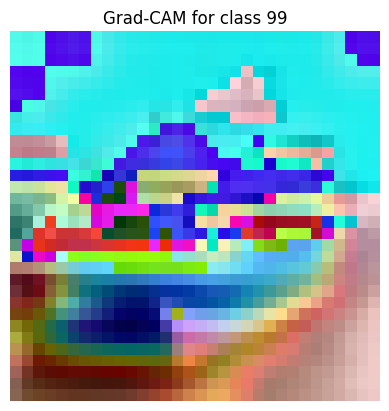

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2


temp_model_for_grad = tf.keras.models.clone_model(model_cifar)
temp_model_for_grad.set_weights(model_cifar.get_weights()) # Copy the trained weights


last_conv_layer_grad = None
for layer in reversed(temp_model_for_grad.layers):
    if isinstance(layer, layers.Conv2D):
        last_conv_layer_grad = layer
        break

if last_conv_layer_grad is None:
    raise ValueError("Could not find a Conv2D layer in the cloned model.")


grad_cam_input = tf.keras.Input(shape=(32, 32, 3))

x = grad_cam_input
last_conv_output = None
logits_output = None



for i, layer in enumerate(temp_model_for_grad.layers):
    x = layer(x)
    if layer is last_conv_layer_grad:
        last_conv_output = x

    if i == len(temp_model_for_grad.layers) - 3:
        logits_output = x


if last_conv_output is None:
    raise ValueError("Last convolutional layer output tensor not found during graph traversal.")
if logits_output is None:
    raise ValueError("Logits output tensor not found during graph traversal.")


grad_model = Model(
    inputs=grad_cam_input,
    outputs=[last_conv_output, logits_output]
)
 --- End of robust grad_model definition ---



img = x_test_cifar_normalized[1]
img_array = np.expand_dims(img, axis=0)

with tf.GradientTape() as tape:

    (conv_output, logits) = grad_model(img_array)


    tape.watch(conv_output)


    class_index = tf.argmax(logits[0])

    loss = logits[0][class_index]


grads = tape.gradient(loss, conv_output)


if grads is None:
    raise ValueError("Gradients could not be computed. Check model and gradient tape setup.")


pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))


conv_output = conv_output[0]


heatmap = conv_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)


heatmap = tf.maximum(heatmap, 0)


max_heatmap = tf.reduce_max(heatmap)
if max_heatmap == 0:
    heatmap = heatmap * 0
else:
    heatmap = heatmap / (max_heatmap + 1e-8)

heatmap = heatmap.numpy()


heatmap = cv2.resize(heatmap, (32, 32))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)


img_display = (img * 255).astype("uint8")
superimposed = heatmap * 0.4 + img_display


plt.imshow(superimposed.astype('uint8'))
plt.axis('off')
plt.title(f"Grad-CAM for class {class_index.numpy()}")
plt.savefig("grad_cam_output.png")
plt.show()

In this task, I implemented Grad-CAM to understand which part of the image the model is focusing on while making predictions. I used the output of the last convolution layer and computed gradients with respect to the predicted class.

The heatmap shows the important regions in the image. I observed that when the prediction is correct, the model focuses more on the object. In some cases, the model also focuses on background regions which can lead to incorrect predictions.

This helps in understanding how the CNN is making decisions.

Grad-CAM improves model interpretability and helps in debugging the model. It can also be used to detect if the model is learning wrong patterns.

# **Task 5**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import tensorflow as tf

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

for layer in base_model.layers:
    layer.trainable = False

print("base model loaded")

base model loaded


Resizing Images

In [ ]:
import tensorflow as tf
from tensorflow import keras

batch_size = 32

if 'x_train_cifar' not in globals():
    (x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = keras.datasets.cifar10.load_data()

x_train_cifar_normalized = x_train_cifar / 255.0
x_test_cifar_normalized = x_test_cifar / 255.0

train_ds = tf.data.Dataset.from_tensor_slices((x_train_cifar_normalized, y_train_cifar))
test_ds = tf.data.Dataset.from_tensor_slices((x_test_cifar_normalized, y_test_cifar))

In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (96,96))
    return image, label

train_ds = train_ds.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)

Building Model

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

print("VGG16 loaded")

VGG16 loaded


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras import layers, models

model_tl = models.Sequential()

model_tl.add(base_model)
model_tl.add(layers.GlobalAveragePooling2D())
model_tl.add(layers.Dense(256, activation='relu'))
model_tl.add(layers.Dropout(0.5))
model_tl.add(layers.Dense(10, activation='softmax'))

In [ ]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_tl = model_tl.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 51ms/step - accuracy: 0.5382 - loss: 1.3300 - val_accuracy: 0.6339 - val_loss: 1.0584
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.6221 - loss: 1.0876 - val_accuracy: 0.6613 - val_loss: 0.9858
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.6443 - loss: 1.0244 - val_accuracy: 0.6670 - val_loss: 0.9545
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.6562 - loss: 0.9857 - val_accuracy: 0.6777 - val_loss: 0.9245
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.6667 - loss: 0.9601 - val_accuracy: 0.6798 - val_loss: 0.9133
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.6753 - loss: 0.9387 - val_accuracy: 0.6861 - val_loss: 0.9002
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.6787 - loss: 0.9228 - val_accuracy: 0.6846 - val_loss: 0.8986
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.6823 -

I used tf.data pipeline to resize images during training instead of storing them in memory. This helped in reducing memory usage and avoided system crash.

In [ ]:
for layer in base_model.layers[-4:]:
    layer.trainable = True

In [ ]:
import tensorflow as tf

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_ft = model_tl.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 51ms/step - accuracy: 0.7030 - loss: 0.8529 - val_accuracy: 0.7069 - val_loss: 0.8461
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7135 - loss: 0.8233 - val_accuracy: 0.7097 - val_loss: 0.8417
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7158 - loss: 0.8177 - val_accuracy: 0.7091 - val_loss: 0.8403
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7192 - loss: 0.8093 - val_accuracy: 0.7084 - val_loss: 0.8393
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7181 - loss: 0.8113 - val_accuracy: 0.7092 - val_loss: 0.8389
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7185 - loss: 0.8089 - val_accuracy: 0.7091 - val_loss: 0.8384
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7169 - loss: 0.8129 - val_accuracy: 0.7099 - val_loss: 0.8380
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.7186 -

In fine tuning, I unfroze some layers and trained the model with a very small learning rate. This helps the model adjust better to the dataset.

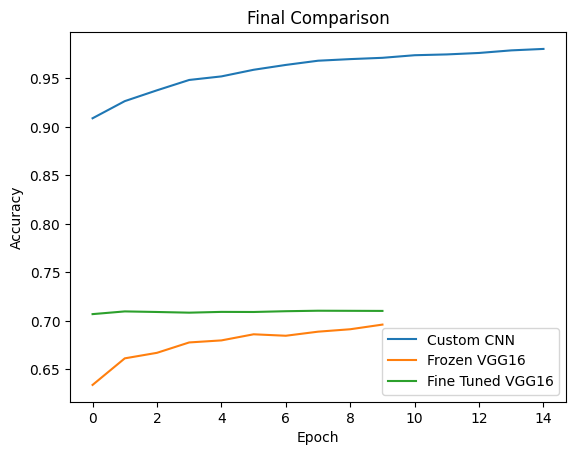

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_accuracy'], label='Custom CNN')
plt.plot(history_tl.history['val_accuracy'], label='Frozen VGG16')
plt.plot(history_ft.history['val_accuracy'], label='Fine Tuned VGG16')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Comparison")
plt.legend()

plt.savefig("final_comparison.png")
plt.show()

From the comparison, transfer learning performs better than training from scratch. The fine tuned model gives the best performance because it adapts pre-trained features to the CIFAR dataset.

Q1
Negative transfer happens when the source dataset is very different from the target dataset, leading to poor performance.

Q2
Lower layers learn general features like edges, while higher layers learn task specific features.

Q3 In real applications, factors like speed, memory and model size are also important.

Q4
For medical data, I would use transfer learning with small learning rate and data augmentation.